In [2]:
!pip install scikit-image

Import Libraries

In [3]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from skimage.feature import local_binary_pattern

Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Set Dataset Paths

In [5]:
train_path = "/content/drive/MyDrive/Leaf_Dataset/CroppedMedLeaves/CroppedMedLeaves/train"
test_path  = "/content/drive/MyDrive/Leaf_Dataset/CroppedMedLeaves/CroppedMedLeaves/test"

Feature Extraction

In [6]:
def extract_features(image):
    image = cv2.resize(image, (128,128))

    # RGB mean
    mean_rgb = np.mean(image, axis=(0,1))

    # HSV mean
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mean_hsv = np.mean(hsv, axis=(0,1))

    # LBP (texture)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")

    (hist, _) = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 10),
        range=(0, 9)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return np.hstack([mean_rgb, mean_hsv, hist])

Load Training Data

In [7]:
X_train, y_train = [], []

for label in os.listdir(train_path):
    label_path = os.path.join(train_path, label)

    if not os.path.isdir(label_path):
        continue

    print("Processing class:", label)

    for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        img = cv2.imread(img_path)

        if img is not None:
            X_train.append(extract_features(img))
            y_train.append(label)

print("Training samples:", len(X_train))

Processing class: 9
Processing class: 7
Processing class: 27
Processing class: 24
Processing class: 22
Processing class: 23
Processing class: 5
Processing class: 8
Processing class: 6
Processing class: 26
Processing class: 4
Processing class: 3
Processing class: 28
Processing class: 29
Processing class: 21
Processing class: 25
Processing class: 18
Processing class: 19
Processing class: 16
Processing class: 20
Processing class: 15
Processing class: 13
Processing class: 2
Processing class: 14
Processing class: 12
Processing class: 17
Processing class: 11
Processing class: 0
Processing class: 10
Processing class: 1
Training samples: 54454


Load Testing Data

In [8]:
X_test, y_test = [], []

for label in os.listdir(test_path):
    label_path = os.path.join(test_path, label)

    if not os.path.isdir(label_path):
        continue

    for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        img = cv2.imread(img_path)

        if img is not None:
            X_test.append(extract_features(img))
            y_test.append(label)

print("Testing samples:", len(X_test))

Testing samples: 4086


Encoding and scaling


In [9]:
X_train = np.array(X_train)
X_test = np.array(X_test)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Number of classes:", len(set(y_train)))

Number of classes: 30


Models

In [10]:
models = {
    "SVM": SVC(kernel='rbf', C=10),
    "Decision Tree": DecisionTreeClassifier(max_depth=20),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

**Model Training and Evaluation**

In [11]:
model_names = []
accuracies = []

print("\nModel Accuracies:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print(f"{name}: {acc*100:.2f}%")

    model_names.append(name)
    accuracies.append(acc * 100)


Model Accuracies:

SVM: 87.89%
Decision Tree: 74.01%
Random Forest: 89.55%
KNN: 89.94%


**Graph**

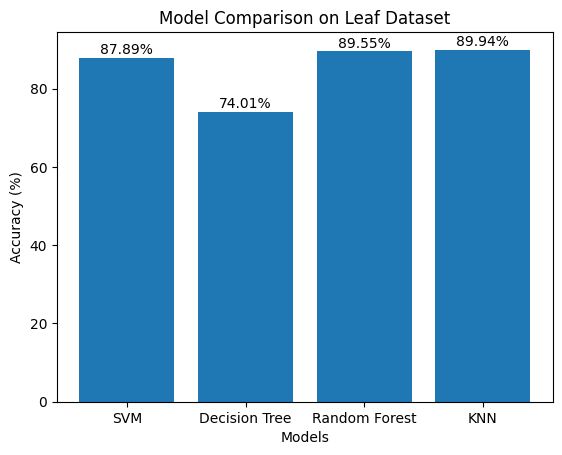

In [12]:
plt.figure()
plt.bar(model_names, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison on Leaf Dataset")

# Value labels
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()